# Outlier-Preserving Group Quantisation

Standard layer-wise quantisation uses one scale for the entire activation tensor.
When outliers exist on specific channels or pixels, that single scale gets dominated
by the outlier magnitude — crushing resolution for all normal-valued elements.

DGQ fixes this with three steps (Equations 4–7):

1. **Detect** which spatial dimension (channel or pixel) contains the outliers — Eq. 4–5
2. **Group** vectors along that dimension by their activation range using K-means
3. **Calibrate** a separate `LinearQuantiser` per group — Eq. 6–7

Outlier vectors get their own large-scale quantiser; normal vectors get a tight one.

In [28]:
import torch
from torch import Tensor
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from typing import Literal

from LinearQuantisation import (
    compute_scale_zeropoint,
    linear_quantise,
    linear_dequantise,
    fake_quantise,
    LinearQuantizer,
)

from LogarithmicQuantisation import (
    compute_log_scale,
    log_quantise,
    log_dequantise,
    log_fake_quantise,
    logQuantiser,
)

## 1. Synthetic activation fixtures

We create two types of outlier activation — matching the two cases in Figure 4(b):

- **Case 1 (pixel outlier):** a few pixel rows have extreme values, all channels normal elsewhere
- **Case 2 (channel outlier):** a few channel columns are extreme across all pixels

In [2]:
def make_pixel_outlier_activation(
    batch: int = 2,
    pixels: int = 32,
    channels: int = 64,
    outlier_pixels: tuple = (0, 5),
    scale: float = 50.0,
    seed: int = 1,
) -> Tensor:
    """
    Activation with outliers on specific pixel rows — Figure 4(b) Case 1.

    All channels of the outlier pixels are set to +scale, making those
    pixels' a_max >> normal pixels' a_max (Equation 4 signal).
    Shape: (batch, pixels, channels)
    """
    torch.manual_seed(seed)
    x = torch.randn(batch, pixels, channels) * 0.1
    for p in outlier_pixels:
        x[:, p, :] = scale
    return x


def make_channel_outlier_activation(
    batch: int = 2,
    pixels: int = 32,
    channels: int = 64,
    outlier_channels: tuple = (3, 10),
    scale: float = 50.0,
    seed: int = 2,
) -> Tensor:
    """
    Activation with outliers on specific channel columns — Figure 4(b) Case 2.

    All pixels of the outlier channels are set to +scale.
    Shape: (batch, pixels, channels)
    """
    torch.manual_seed(seed)
    x = torch.randn(batch, pixels, channels) * 0.1
    for c in outlier_channels:
        x[:, :, c] = scale
    return x


x_pixel   = make_pixel_outlier_activation()
x_channel = make_channel_outlier_activation()
print(f"Pixel-outlier tensor:   {x_pixel.shape}")
print(f"Channel-outlier tensor: {x_channel.shape}")

Pixel-outlier tensor:   torch.Size([2, 32, 64])
Channel-outlier tensor: torch.Size([2, 32, 64])


### Visualise — Figure 4(b) style boxplots

Each box shows the distribution of values in one vector along the selected dimension.
Outlier vectors will have a dramatically different median/range from the rest.

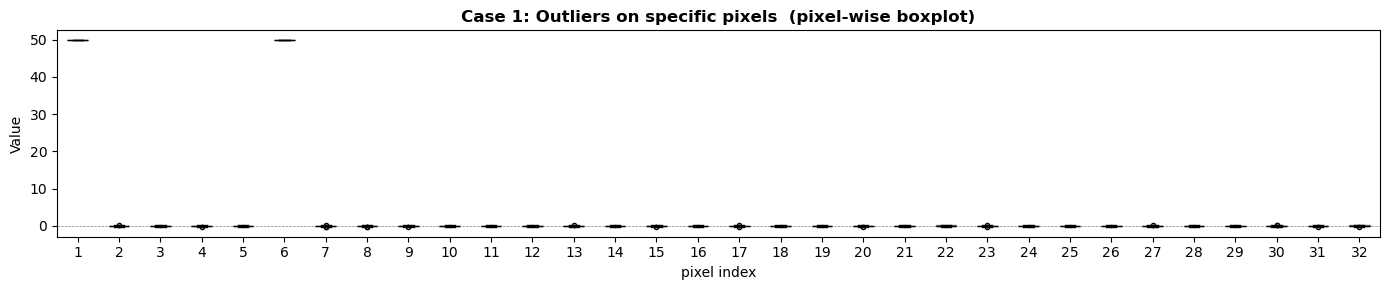

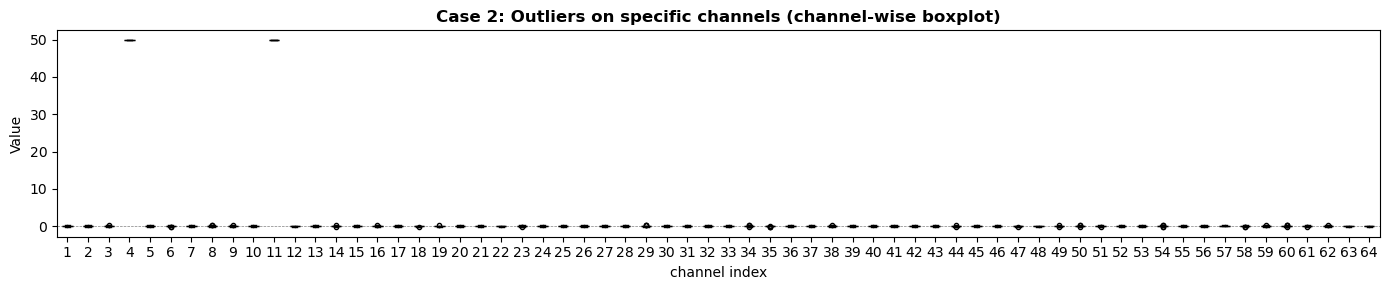

In [3]:
def plot_activation_boxplots(x: Tensor, title: str, dim: str = "pixel") -> None:
    """
    Reproduce the Figure 4(b) boxplot style.

    dim='pixel'   → one box per pixel   (each box = that pixel's channel values)
    dim='channel' → one box per channel (each box = that channel's pixel values)
    """
    # Collapse batch by taking the max-magnitude sample
    x_2d = x[x.abs().sum(dim=(1,2)).argmax()]  # (pixels, channels)

    if dim == "pixel":
        data   = [x_2d[i, :].numpy() for i in range(x_2d.shape[0])]
        xlabel = "pixel index"
    else:
        data   = [x_2d[:, j].numpy() for j in range(x_2d.shape[1])]
        xlabel = "channel index"

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.boxplot(data, sym=".", whis=1.5, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.5),
               medianprops=dict(color="black"))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Value")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    plt.tight_layout()
    plt.show()


plot_activation_boxplots(x_pixel,   "Case 1: Outliers on specific pixels  (pixel-wise boxplot)",   dim="pixel")
plot_activation_boxplots(x_channel, "Case 2: Outliers on specific channels (channel-wise boxplot)", dim="channel")

## 2. Variability metric

$$D_d = \left(\max_i a^{\max}_{i,d} - \min_i a^{\max}_{i,d}\right) + \left(\max_i a^{\min}_{i,d} - \min_i a^{\min}_{i,d}\right)$$

For each index $i$ along dimension $d$, we record the max and min of that vector.
$D_d$ measures how much those per-vector extremes vary across $i$.
A large $D_d$ means values along this dimension are non-uniform — a signature of localised outliers.

In [4]:
Dimension = Literal["pixel", "channel"]


def compute_variability(x: Tensor, dim: Dimension) -> float:
    """
    Compute D_d — Equation 4.

    Parameters
    ----------
    x   : Tensor  — shape (batch, pixels, channels)
    dim : 'pixel' or 'channel'

    Returns
    -------
    D_d : float
    """
    # Collapse batch with signed extremes
    x_max_batch = x.max(dim=0).values   # (pixels, channels)
    x_min_batch = x.min(dim=0).values   # (pixels, channels)

    # For 'pixel'  dim: each vector spans channels → reduce axis 1
    #                   → a_max[i] = max value of pixel i across channels
    # For 'channel' dim: each vector spans pixels  → reduce axis 0
    #                   → a_max[j] = max value of channel j across pixels
    reduce_axis = 1 if dim == "pixel" else 0

    a_max = x_max_batch.max(dim=reduce_axis).values   # (n_vectors,)
    a_min = x_min_batch.min(dim=reduce_axis).values   # (n_vectors,)

    # Equation 4
    D_d = (
        (a_max.max() - a_max.min()) +
        (a_min.max() - a_min.min())
    )
    return D_d.item()


# Verify: pixel-outlier tensor should give D_pixel >> D_channel
for name, x in [("pixel-outlier", x_pixel), ("channel-outlier", x_channel)]:
    D_p = compute_variability(x, "pixel")
    D_c = compute_variability(x, "channel")
    winner = "pixel" if D_p >= D_c else "channel"
    print(f"{name:18s}  D_pixel={D_p:7.3f}  D_channel={D_c:7.3f}  → selects '{winner}' dim")

pixel-outlier       D_pixel=100.213  D_channel=  0.242  → selects 'pixel' dim
channel-outlier     D_pixel=  0.172  D_channel=100.198  → selects 'channel' dim


## 3. Dimension selection

$$d^* = \arg\max_d D_d$$

In [5]:
def select_dimension(x: Tensor) -> Dimension:
    """
    Select d* = argmax_d D_d — Equation 5.

    Parameters
    ----------
    x : Tensor  — shape (batch, pixels, channels)

    Returns
    -------
    'pixel' or 'channel'
    """
    D_pixel   = compute_variability(x, "pixel")
    D_channel = compute_variability(x, "channel")
    return "pixel" if D_pixel >= D_channel else "channel"


print(f"Pixel-outlier tensor   → d* = '{select_dimension(x_pixel)}'   (expected: 'pixel')")
print(f"Channel-outlier tensor → d* = '{select_dimension(x_channel)}' (expected: 'channel')")

Pixel-outlier tensor   → d* = 'pixel'   (expected: 'pixel')
Channel-outlier tensor → d* = 'channel' (expected: 'channel')


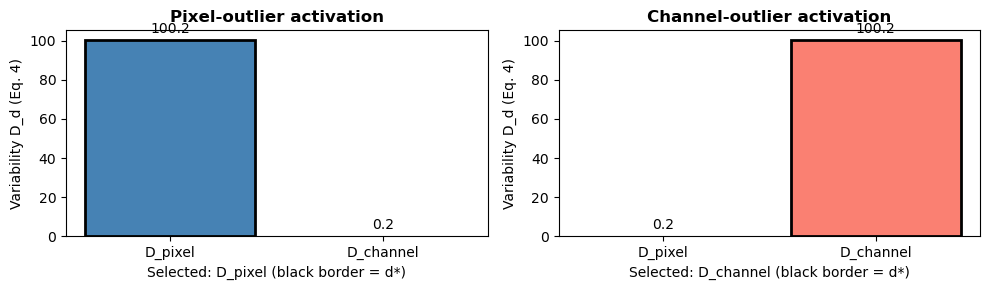

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, (name, x) in zip(axes, [("Pixel-outlier", x_pixel), ("Channel-outlier", x_channel)]):
    D_p = compute_variability(x, "pixel")
    D_c = compute_variability(x, "channel")
    bars = ax.bar(["D_pixel", "D_channel"], [D_p, D_c],
                  color=["steelblue", "salmon"])
    winner_idx = 0 if D_p >= D_c else 1
    bars[winner_idx].set_edgecolor("black")
    bars[winner_idx].set_linewidth(2)
    ax.set_title(f"{name} activation", fontweight="bold")
    ax.set_ylabel("Variability D_d (Eq. 4)")
    ax.bar_label(bars, fmt="%.1f", padding=3)
    selected = "D_pixel" if D_p >= D_c else "D_channel"
    ax.set_xlabel(f"Selected: {selected} (black border = d*)")

plt.tight_layout()
plt.show()

## 4. K-means grouping by activation range

Once we know which dimension to group along, we cluster the vectors by their
activation range `(vec_max - vec_min)`. Outlier vectors have large range;
normal vectors have small range. K-means separates them.

In [7]:
def kmeans_1d(values: Tensor, K: int, n_iter: int = 50) -> Tensor:
    """
    1-D K-means clustering with K-means++ initialisation.

    Parameters
    ----------
    values : Tensor  — shape (N,)  scalars to cluster
    K      : int     — number of clusters
    n_iter : int     — max Lloyd iterations

    Returns
    -------
    labels : LongTensor  — shape (N,)  cluster index per element
    """
    N = values.shape[0]
    if K == 1:
        return torch.zeros(N, dtype=torch.long)

    v = values.float()

    # K-means++ initialisation
    torch.manual_seed(0)
    centroids = [v[torch.randint(N, (1,)).item()]]
    for _ in range(K - 1):
        dists = torch.stack([(v - c).pow(2) for c in centroids]).min(dim=0).values
        probs = dists / dists.sum()
        centroids.append(v[torch.multinomial(probs, 1).item()])
    centroids = torch.stack(centroids)   # (K,)

    labels = torch.zeros(N, dtype=torch.long)
    for _ in range(n_iter):
        dists      = (v.unsqueeze(1) - centroids.unsqueeze(0)).abs()   # (N, K)
        new_labels = dists.argmin(dim=1)
        if torch.equal(new_labels, labels):
            break
        labels = new_labels
        for k in range(K):
            mask = labels == k
            if mask.any():
                centroids[k] = v[mask].mean()

    return labels


def group_by_range(x: Tensor, dim: Dimension, K: int) -> tuple[Tensor, Tensor]:
    """
    Cluster vectors along `dim` into K groups by activation range.

    The range (vec_max - vec_min) is the scalar used for clustering —
    it directly determines the quantiser scale needed for each vector
    (Equation 6: s_k = (max_x - min_x) / 2^b).

    Parameters
    ----------
    x   : Tensor  — shape (batch, pixels, channels)
    dim : 'pixel' or 'channel'
    K   : int     — number of groups

    Returns
    -------
    labels : LongTensor  — shape (n_vectors,)  group index per vector
    ranges : Tensor      — shape (n_vectors,)  range per vector
    """
    x_max_batch = x.max(dim=0).values   # (pixels, channels)
    x_min_batch = x.min(dim=0).values

    reduce_axis = 1 if dim == "pixel" else 0

    vec_max = x_max_batch.max(dim=reduce_axis).values   # (n_vectors,)
    vec_min = x_min_batch.min(dim=reduce_axis).values
    ranges  = vec_max - vec_min

    labels = kmeans_1d(ranges, K=K)
    return labels, ranges

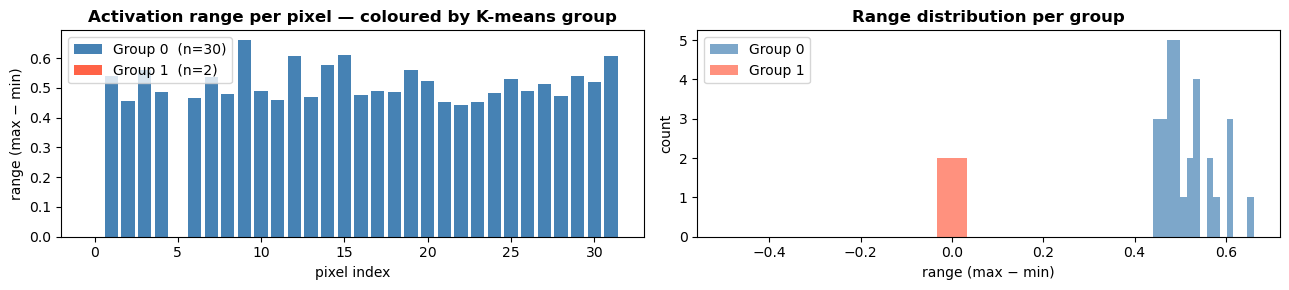

Group sizes: [30, 2]
Group mean ranges: [0.5146727561950684, 0.0]


In [8]:
K = 2
labels, ranges = group_by_range(x_pixel, dim="pixel", K=K)

colours = ["steelblue", "tomato", "seagreen", "goldenrod"][:K]

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

# Left: range per pixel, coloured by group
ax = axes[0]
for k in range(K):
    mask = labels == k
    ax.bar(torch.where(mask)[0].numpy(), ranges[mask].numpy(),
           color=colours[k], label=f"Group {k}  (n={mask.sum()})")
ax.set_title("Activation range per pixel — coloured by K-means group", fontweight="bold")
ax.set_xlabel("pixel index")
ax.set_ylabel("range (max − min)")
ax.legend()

# Right: range histogram per group
ax = axes[1]
for k in range(K):
    mask = labels == k
    ax.hist(ranges[mask].numpy(), bins=15, alpha=0.7,
            color=colours[k], label=f"Group {k}")
ax.set_title("Range distribution per group", fontweight="bold")
ax.set_xlabel("range (max − min)")
ax.set_ylabel("count")
ax.legend()

plt.tight_layout()
plt.show()

print("Group sizes:", [(labels == k).sum().item() for k in range(K)])
print("Group mean ranges:", [ranges[labels == k].mean().item() for k in range(K)])

## 5. Per-group calibration

**Equation 6** — for each group $k$, calibrate scale and zero-point from all values in that group:
$$s_k = \frac{\max x_k - \min x_k}{2^b}, \quad z_k = \min x_k$$

**Equation 7** — store one full set of group quantisers per denoising timestep:
$$S = \{s_0, s_1, \ldots, s_{T-1}\}, \quad Z = \{z_0, z_1, \ldots, z_{T-1}\}$$

In [17]:
from dataclasses import dataclass, field


@dataclass
class GroupQuantiserParams:
    """
    Calibrated parameters for one timestep.

    Attributes
    ----------
    dim        : selected dimension ('pixel' or 'channel')
    labels     : LongTensor (n_vectors,)  — group assignment per vector
    quantisers : list of K LinearQuantiser instances
    K          : number of groups
    """
    dim       : str
    labels    : Tensor
    quantisers: list
    K         : int


def calibrate_groups(
    x: Tensor,
    dim: Dimension,
    K: int,
    bit_width: int,
) -> GroupQuantiserParams:
    """
    Calibrate K group quantisers for one timestep — Equation 6.

    For each group k, gather all activation values belonging to vectors
    in that group and compute s_k, z_k from their observed range.

    Parameters
    ----------
    x         : Tensor  — shape (batch, pixels, channels)
    dim       : selected dimension
    K         : number of groups
    bit_width : int

    Returns
    -------
    GroupQuantiserParams
    """
    labels, _ = group_by_range(x, dim, K)

    quantisers = []
    for k in range(K):
        mask = labels == k

        # Gather all values belonging to this group's vectors
        if dim == "pixel":
            group_vals = x[:, mask, :].reshape(-1)
        else:
            group_vals = x[:, :, mask].reshape(-1)

        s, z = compute_scale_zeropoint(group_vals.min(), group_vals.max(), bit_width)

        q = LinearQuantizer(bit_width=bit_width)
        q.set_params(s, z)
        quantisers.append(q)

    return GroupQuantiserParams(dim=dim, labels=labels, quantisers=quantisers, K=K)


# Quick check
params = calibrate_groups(x_pixel, dim="pixel", K=2, bit_width=8)
for k, q in enumerate(params.quantisers):
    n = (params.labels == k).sum().item()
    print(f"Group {k}: {n:2d} vectors  scale={q.scale.item():.5f}  zero_point={q.zero_point.item():.3f}")

Group 0: 30 vectors  scale=0.00287  zero_point=-0.395
Group 1:  2 vectors  scale=0.00000  zero_point=50.000


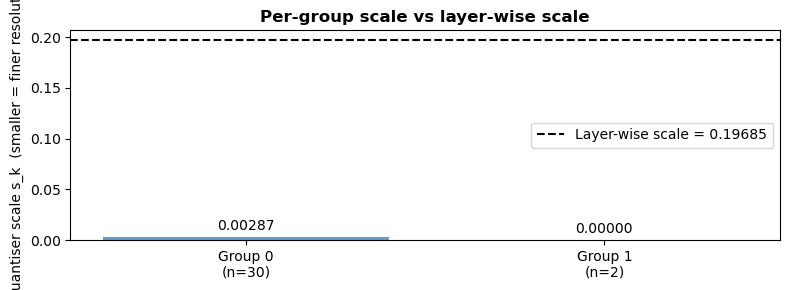

Layer-wise scale: 0.19685
Normal group gets scale 0.00000 — 5039455063.0x finer resolution than layer-wise


In [18]:
# Layer-wise baseline: single scale for the whole tensor
s_lw, z_lw = compute_scale_zeropoint(x_pixel.min(), x_pixel.max(), bit_width=8)

fig, ax = plt.subplots(figsize=(8, 3))

group_scales = [q.scale.item() for q in params.quantisers]
group_sizes  = [(params.labels == k).sum().item() for k in range(params.K)]
labels_str   = [f"Group {k}\n(n={group_sizes[k]})" for k in range(params.K)]

bars = ax.bar(labels_str, group_scales, color=["steelblue", "tomato"], alpha=0.8)
ax.axhline(s_lw.item(), color="black", linestyle="--", linewidth=1.5,
           label=f"Layer-wise scale = {s_lw.item():.5f}")
ax.bar_label(bars, fmt="%.5f", padding=3)
ax.set_title("Per-group scale vs layer-wise scale", fontweight="bold")
ax.set_ylabel("Quantiser scale s_k  (smaller = finer resolution)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Layer-wise scale: {s_lw.item():.5f}")
print(f"Normal group gets scale {min(group_scales):.5f} — "
      f"{s_lw.item()/min(group_scales):.1f}x finer resolution than layer-wise")

## 6. Apply group quantisation at inference

In [19]:
def apply_group_quantisation(
    x: Tensor,
    params: GroupQuantiserParams,
) -> Tensor:
    """
    Fake-quantise x using the calibrated group quantisers.

    Builds per-element scale and zero-point tensors by broadcasting
    each group's parameters onto the vectors it owns, then calls
    fake_quantise once for the full tensor.

    Parameters
    ----------
    x      : Tensor  — shape (batch, pixels, channels)
    params : GroupQuantiserParams

    Returns
    -------
    x_dq : Tensor  — fake-quantised, same shape as x
    """
    batch, pixels, channels = x.shape
    labels  = params.labels
    K       = params.K

    if params.dim == "pixel":
        n_vec = pixels
        scale_vec = torch.zeros(n_vec)
        zp_vec    = torch.zeros(n_vec)
        for k in range(K):
            mask = labels == k
            scale_vec[mask] = params.quantisers[k].scale.item()
            zp_vec[mask]    = params.quantisers[k].zero_point.item()
        # Broadcast: (1, pixels, 1) against (batch, pixels, channels)
        scale_bc = scale_vec.view(1, pixels, 1)
        zp_bc    = zp_vec.view(1, pixels, 1)

    else:  # channel
        n_vec = channels
        scale_vec = torch.zeros(n_vec)
        zp_vec    = torch.zeros(n_vec)
        for k in range(K):
            mask = labels == k
            scale_vec[mask] = params.quantisers[k].scale.item()
            zp_vec[mask]    = params.quantisers[k].zero_point.item()
        # Broadcast: (1, 1, channels) against (batch, pixels, channels)
        scale_bc = scale_vec.view(1, 1, channels)
        zp_bc    = zp_vec.view(1, 1, channels)

    bit_width = params.quantisers[0].bit_width
    return fake_quantise(x, scale_bc, zp_bc, bit_width)

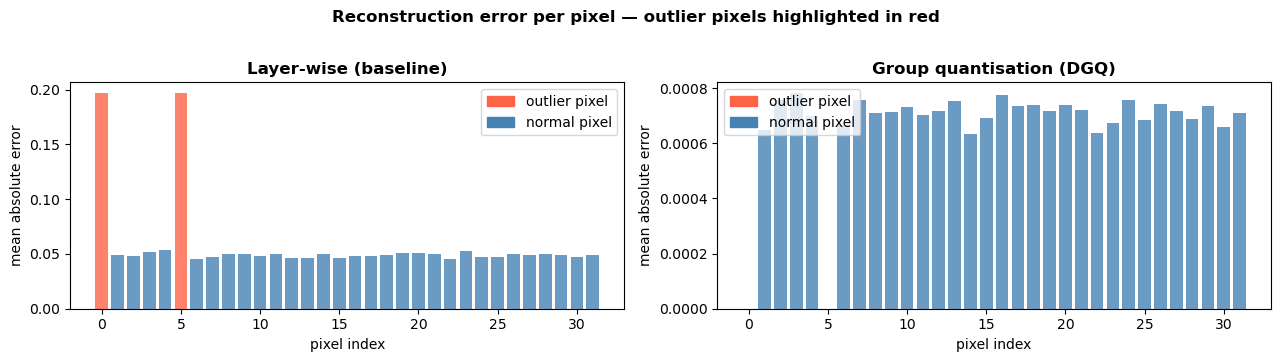

Normal pixel MAE  — layer-wise: 0.04888  group: 0.00071  (68.5x improvement)


In [20]:
# Compute errors
x_group = apply_group_quantisation(x_pixel, params)
x_lw    = fake_quantise(x_pixel, s_lw, z_lw, bit_width=8)

err_group = (x_group - x_pixel).abs().mean(dim=(0, 2)).numpy()  # (pixels,)
err_lw    = (x_lw    - x_pixel).abs().mean(dim=(0, 2)).numpy()  # (pixels,)

outlier_pixels = [0, 5]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

for ax, (err, method) in zip(axes, [
    (err_lw,    "Layer-wise (baseline)"),
    (err_group, "Group quantisation (DGQ)"),
]):
    colours_bar = ["tomato" if i in outlier_pixels else "steelblue"
                   for i in range(len(err))]
    ax.bar(range(len(err)), err, color=colours_bar, alpha=0.8)
    ax.set_title(method, fontweight="bold")
    ax.set_xlabel("pixel index")
    ax.set_ylabel("mean absolute error")
    red_patch  = mpatches.Patch(color="tomato",    label="outlier pixel")
    blue_patch = mpatches.Patch(color="steelblue", label="normal pixel")
    ax.legend(handles=[red_patch, blue_patch])

plt.suptitle(
    "Reconstruction error per pixel — outlier pixels highlighted in red",
    fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

normal_idx = [i for i in range(x_pixel.shape[1]) if i not in outlier_pixels]
print(f"Normal pixel MAE  — layer-wise: {err_lw[normal_idx].mean():.5f}  "
      f"group: {err_group[normal_idx].mean():.5f}  "
      f"({err_lw[normal_idx].mean()/err_group[normal_idx].mean():.1f}x improvement)")

## 7. Full GroupQuantiser module — Equation 7

Stores one `GroupQuantiserParams` per denoising timestep:
$$S = \{s_0, s_1, \ldots, s_{T-1}\}, \quad Z = \{z_0, z_1, \ldots, z_{T-1}\}$$

In [22]:
class GroupQuantiser(nn.Module):
    """
    Outlier-preserving group quantiser for one U-Net layer.

    Stores one GroupQuantiserParams per denoising timestep (Equation 7).
    During calibration call calibrate(x, timestep) for each timestep.
    During inference call forward(x, timestep).

    Parameters
    ----------
    K         : int  — number of groups (paper uses 8 or 16)
    bit_width : int  — activation bit-width
    auto_dim  : bool — if True, select dimension automatically (Eq. 5)
    fixed_dim : str  — used when auto_dim=False
    """

    def __init__(
        self,
        K: int,
        bit_width: int,
        auto_dim: bool = True,
        fixed_dim: Dimension = "channel",
    ):
        super().__init__()
        self.K         = K
        self.bit_width = bit_width
        self.auto_dim  = auto_dim
        self.fixed_dim = fixed_dim

        # Maps timestep index → GroupQuantiserParams  (Equation 7)
        self._params: dict[int, GroupQuantiserParams] = {}

    def calibrate(self, x: Tensor, timestep: int) -> None:
        """
        Calibrate group quantisers for one denoising timestep.

        Parameters
        ----------
        x        : Tensor  — (batch, pixels, channels)  activation at this timestep
        timestep : int     — denoising step index t ∈ {0, ..., T-1}
        """
        dim    = select_dimension(x) if self.auto_dim else self.fixed_dim
        params = calibrate_groups(x, dim=dim, K=self.K, bit_width=self.bit_width)
        self._params[timestep] = params

    @property
    def is_calibrated(self) -> bool:
        return len(self._params) > 0

    @property
    def n_timesteps(self) -> int:
        return len(self._params)

    def forward(self, x: Tensor, timestep: int) -> Tensor:
        """
        Fake-quantise x using the params calibrated for this timestep.

        Falls back to the nearest calibrated timestep if `timestep` was
        not seen during calibration.

        Parameters
        ----------
        x        : Tensor  — (batch, pixels, channels)
        timestep : int

        Returns
        -------
        x_dq : Tensor  — same shape as x
        """
        if not self.is_calibrated:
            raise RuntimeError(
                "GroupQuantiser.forward() called before calibration. "
                "Call calibrate(x, timestep) for each timestep first."
            )

        if timestep not in self._params:
            available = sorted(self._params.keys())
            timestep  = min(available, key=lambda t: abs(t - timestep))

        return apply_group_quantisation(x, self._params[timestep])

    def extra_repr(self) -> str:
        return (
            f"K={self.K}, bit_width={self.bit_width}, "
            f"auto_dim={self.auto_dim}, "
            f"calibrated_timesteps={self.n_timesteps}"
        )

Test

In [23]:
torch.manual_seed(0)
T         = 5    # denoising timesteps
K         = 8    # groups
bit_width = 8

gq = GroupQuantiser(K=K, bit_width=bit_width, auto_dim=True)

# ── calibration pass (one activation tensor per timestep) ────────────────
print("Calibrating...")
for t in range(T):
    # In real PTQ: this comes from running a calibration prompt through SD
    x_t = make_pixel_outlier_activation(
        pixels=64, channels=128, seed=t,
        outlier_pixels=(0, 1), scale=40.0 + t * 5
    )
    gq.calibrate(x_t, timestep=t)
    dim_selected = gq._params[t].dim
    print(f"  t={t}  dim='{dim_selected}'  "
          f"scales={[f'{q.scale.item():.4f}' for q in gq._params[t].quantisers]}")

print(f"\nGroupQuantiser calibrated over {gq.n_timesteps} timesteps")
print(gq)

Calibrating...
  t=0  dim='pixel'  scales=['0.0021', '0.0000', '0.0029', '0.0033', '0.0025', '0.0031', '0.0027', '0.0023']
  t=1  dim='pixel'  scales=['0.0023', '0.0000', '0.0026', '0.0029', '0.0021', '0.0029', '0.0025', '0.0028']
  t=2  dim='pixel'  scales=['0.0030', '0.0000', '0.0028', '0.0020', '0.0024', '0.0022', '0.0025', '0.0028']
  t=3  dim='pixel'  scales=['0.0021', '0.0000', '0.0027', '0.0026', '0.0027', '0.0023', '0.0029', '0.0028']
  t=4  dim='pixel'  scales=['0.0029', '0.0000', '0.0029', '0.0025', '0.0027', '0.0023', '0.0031', '0.0021']

GroupQuantiser calibrated over 5 timesteps
GroupQuantiser(K=8, bit_width=8, auto_dim=True, calibrated_timesteps=5)


In [24]:
# ── inference pass ───────────────────────────────────────────────────────
print("Inference errors per timestep:")
print(f"{'t':>4}  {'group MAE':>10}  {'layerwise MAE':>14}  {'improvement':>12}")
print("-" * 46)

for t in range(T):
    x_t = make_pixel_outlier_activation(
        pixels=64, channels=128, seed=t + 100,   # fresh batch, same distribution
        outlier_pixels=(0, 1), scale=40.0 + t * 5
    )

    # Group quantisation
    x_dq_group = gq(x_t, timestep=t)
    mae_group  = (x_dq_group - x_t).abs().mean().item()

    # Layer-wise baseline
    s_lw, z_lw = compute_scale_zeropoint(x_t.min(), x_t.max(), bit_width=8)
    x_dq_lw    = fake_quantise(x_t, s_lw, z_lw, bit_width=8)
    mae_lw     = (x_dq_lw - x_t).abs().mean().item()

    print(f"{t:>4}  {mae_group:>10.5f}  {mae_lw:>14.5f}  {mae_lw/mae_group:>11.1f}x")

Inference errors per timestep:
   t   group MAE   layerwise MAE   improvement
----------------------------------------------
   0     0.00069         0.04339         63.1x
   1     0.00069         0.04842         70.2x
   2     0.00069         0.05378         78.2x
   3     0.00067         0.05898         88.0x
   4     0.00068         0.06596         97.0x
